# **CallGAT: Graph Attention Temporal for Multimodal Volatility Prediction from Earnings Calls**

### Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import datetime
from tqdm import tqdm
from statistics import mean
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, LSTM, Conv1D, MaxPooling1D, Dropout, Activation , Masking, Bidirectional, TimeDistributed, Input,concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error
import math
from tensorflow.keras.layers import dot, multiply, concatenate
import torch
import torch.nn as nn
import torch.nn.functional as F


In [2]:
with open('./audio_featDict.pkl', 'rb') as f:
    audio_featDict=pickle.load(f)

with open('./audio_featDictMark2.pkl', 'rb') as f:
    audio_featDictMark2=pickle.load(f)

with open('./audio_featDict_MFCC.pkl', 'rb') as f:
    audio_featDictMFCC=pickle.load(f)

traindf= pd.read_csv("./train_split_Avg_Series_WITH_LOG.csv")
testdf=pd.read_csv("./test_split_Avg_Series_WITH_LOG.csv")
valdf=pd.read_csv("./val_split_Avg_Series_WITH_LOG.csv")

single_traindf=pd.read_csv("./train_split_SeriesSingleDayVol3.csv")
single_testdf=pd.read_csv("./test_split_SeriesSingleDayVol3.csv")
single_valdf=pd.read_csv("./val_split_SeriesSingleDayVol3.csv")



In [3]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Find a company with available audio features
# for company in combined_audio_features.keys():
#     if combined_audio_features[company]:
#         break
# else:
#     print("No company with audio features found.")
#     raise KeyError("No audio features available for any company.")

# # Now use this company for plotting
# clips = combined_audio_features[company]


# # Extract all feature values for each clip
# feature_values = [clip for clip in clips.values()]

# # Convert to numpy array for easier manipulation
# feature_values = np.array(feature_values)

# # Calculate statistics for each feature across all clips
# feature_means = np.mean(feature_values, axis=0)
# feature_stds = np.std(feature_values, axis=0)
# feature_mins = np.min(feature_values, axis=0)
# feature_maxs = np.max(feature_values, axis=0)

# # Plotting
# fig, axes = plt.subplots(13, 4, figsize=(20, 50))  # 52 features, 13 rows, 4 columns
# axes = axes.ravel()  # Flatten the axes array for easier indexing

# for i in range(52):
#     ax = axes[i]
#     ax.plot(range(1, len(clips) + 1), feature_values[:, i], 'o-', label=f'Feature {i+1}')
#     ax.axhline(y=feature_means[i], color='r', linestyle='--', label='Mean')
#     ax.axhline(y=feature_means[i] + 2*feature_stds[i], color='g', linestyle=':', label='Mean + 2*Std')
#     ax.axhline(y=feature_means[i] - 2*feature_stds[i], color='g', linestyle=':', label='Mean - 2*Std')
#     ax.set_title(f'Feature {i+1}')
#     ax.set_xlabel('Clip Number')
#     ax.set_ylabel('Feature Value')
#     ax.legend()

#     # Add text annotations for min, max, and std
#     ax.text(0.05, 0.95, f'Min: {feature_mins[i]:.2f}\nMax: {feature_maxs[i]:.2f}\nStd: {feature_stds[i]:.2f}',
#             transform=ax.transAxes, verticalalignment='top')

# plt.tight_layout()
# plt.show()

# # Print summary statistics
# print("Feature Statistics:")
# for i in range(52):
#     print(f"Feature {i+1}:")
#     print(f"  Mean: {feature_means[i]:.2f}")
#     print(f"  Std Dev: {feature_stds[i]:.2f}")
#     print(f"  Min: {feature_mins[i]:.2f}")
#     print(f"  Max: {feature_maxs[i]:.2f}")
#     print(f"  Range: {feature_maxs[i] - feature_mins[i]:.2f}")
#     print()


In [4]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Step 1: Filter companies with at least one clip
# valid_companies = {company: clips for company, clips in combined_audio_features.items() if clips}

# if not valid_companies:
#     raise ValueError("No companies with available audio features.")

# # Step 2: Determine minimum number of clips across companies
# min_clip_count = min(len(clips) for clips in valid_companies.values())

# # Step 3: Collect all clips up to min_clip_count from each company
# aggregated_features = []

# for company, clips in valid_companies.items():
#     clips_sorted = list(clips.values())[:min_clip_count]  # get first N clips
#     aggregated_features.extend(clips_sorted)

# # Step 4: Convert to numpy array
# aggregated_features = np.array(aggregated_features)  # Shape: (num_companies * N, num_features)

# # Step 5: Calculate stats
# feature_means = np.mean(aggregated_features, axis=0)
# feature_stds = np.std(aggregated_features, axis=0)
# feature_mins = np.min(aggregated_features, axis=0)
# feature_maxs = np.max(aggregated_features, axis=0)

# # Step 6: Plot
# fig, axes = plt.subplots(13, 4, figsize=(20, 50))  # 52 features
# axes = axes.ravel()

# for i in range(52):
#     ax = axes[i]
#     ax.plot(range(1, len(aggregated_features) + 1), aggregated_features[:, i], 'o-', label=f'Feature {i+1}')
#     ax.axhline(y=feature_means[i], color='r', linestyle='--', label='Mean')
#     ax.axhline(y=feature_means[i] + 2*feature_stds[i], color='g', linestyle=':', label='Mean + 2*Std')
#     ax.axhline(y=feature_means[i] - 2*feature_stds[i], color='g', linestyle=':', label='Mean - 2*Std')
#     ax.set_title(f'Feature {i+1}')
#     ax.set_xlabel('Clip Index (Across Companies)')
#     ax.set_ylabel('Feature Value')
#     if i == 0:  # only add legend once
#         ax.legend()

#     ax.text(0.05, 0.95, f'Min: {feature_mins[i]:.2f}\nMax: {feature_maxs[i]:.2f}\nStd: {feature_stds[i]:.2f}',
#             transform=ax.transAxes, verticalalignment='top')

# plt.tight_layout()
# plt.show()

# # Step 7: Print stats
# print("Cross-Company Audio Feature Statistics:")
# for i in range(52):
#     print(f"Feature {i+1}:")
#     print(f"  Mean: {feature_means[i]:.2f}")
#     print(f"  Std Dev: {feature_stds[i]:.2f}")
#     print(f"  Min: {feature_mins[i]:.2f}")
#     print(f"  Max: {feature_maxs[i]:.2f}")
#     print(f"  Range: {feature_maxs[i] - feature_mins[i]:.2f}")
#     print()


In [5]:
print(traindf.head(1))

  ticker           name  year  month  day          text_file_name  future_2  \
0    CMA  Comerica Inc.  2017      1   17  Comerica Inc._20170117 -3.989002   

   future_3  future_4  future_5  ...  past_21  past_22  past_23   past_24  \
0 -4.188783 -4.306947 -4.414121  ... -4.73101 -4.72701 -4.66876 -4.682231   

    past_25   past_26   past_27   past_28   past_29   past_30  
0 -4.630636 -4.635296 -4.557755 -4.564541 -4.581987 -4.543522  

[1 rows x 64 columns]


### AutoEncoder Audio Encoding

In [6]:
def concatenate_audio_features(audio_featDict, audio_featDictMark2, audio_featDictMFCC):
    combined_features = {}
    for company in audio_featDict.keys():
        if company in audio_featDictMark2 and company in audio_featDictMFCC:
            combined_features[company] = {}
            for clip in audio_featDict[company].keys():
                if clip in audio_featDictMark2[company] and clip in audio_featDictMFCC[company]:
                    combined_features[company][clip] = np.concatenate([
                        audio_featDict[company][clip],
                        audio_featDictMark2[company][clip],
                        audio_featDictMFCC[company][clip]
                    ])
    return combined_features

# Concatenate features
combined_audio_features = concatenate_audio_features(audio_featDict, audio_featDictMark2, audio_featDictMFCC)

In [7]:
print(list(combined_audio_features.keys()))


['3M Company_20170425', '3M Company_20170725', 'A.O. Smith Corp_20170726', 'Abbott Laboratories_20171018', 'AbbVie Inc._20170427', 'AbbVie Inc._20170728', 'AbbVie Inc._20171027', 'ABIOMED Inc_20170504', 'Activision Blizzard_20170209', 'Activision Blizzard_20170504', 'Adobe Systems Inc_20170316', 'Advance Auto Parts_20170524', 'Advanced Micro Devices Inc_20170501', 'Advanced Micro Devices Inc_20170725', 'Advanced Micro Devices Inc_20171024', 'AES Corp_20170508', 'AES Corp_20171102', 'Aetna Inc_20170131', 'Aetna Inc_20170502', 'Aetna Inc_20171031', 'Agilent Technologies Inc_20170214', 'Akamai Technologies Inc_20170207', 'Akamai Technologies Inc_20170502', 'Alaska Air Group Inc_20170208', 'Alaska Air Group Inc_20171025', 'Alexion Pharmaceuticals_20171026', 'Align Technology_20170131', 'Align Technology_20170427', 'Align Technology_20170727', 'Allegion_20170209', 'Allegion_20170427', 'Allergan, Plc_20170803', 'Alliance Data Systems_20170126', 'Alliance Data Systems_20170420', 'Alliance Dat

In [8]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import seaborn as sns

# def flatten_features(feature_dict, expected_length=None, drop_index=4):
#     rows, labels, dropped = [], [], []

#     for company, clips in feature_dict.items():
#         for clip_name, features in clips.items():
#             # Drop Feature 5 (index 4)
#             if len(features) <= drop_index:
#                 dropped.append((company, clip_name, "Too short"))
#                 continue

#             filtered = np.delete(features, drop_index)

#             # If it's the first feature, set expected length
#             if expected_length is None:
#                 expected_length = len(filtered)

#             # Skip if length is inconsistent
#             if len(filtered) != expected_length:
#                 dropped.append((company, clip_name, len(filtered)))
#                 continue

#             rows.append(filtered)
#             labels.append((company, clip_name))

#     print(f"Dropped {len(dropped)} clips due to inconsistent shape.")
#     return np.array(rows), labels


# X_raw, meta_labels = flatten_features(combined_audio_features)

# # Step 2: Standardize
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_raw)

# # Step 3: Optional PCA for noise reduction
# pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
# X_pca = pca.fit_transform(X_scaled)

# print(f"PCA reduced dimensions: {X_pca.shape[1]}")

# # Step 4: KMeans Clustering (Try other clustering methods too)
# n_clusters = 2  # Assume high/low confidence – adjust based on data distribution
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# cluster_labels = kmeans.fit_predict(X_pca)

# # Step 5: Visualization with t-SNE
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_tsne = tsne.fit_transform(X_pca)

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_labels, palette='Set2')
# plt.title("t-SNE Clustering of Audio Embeddings")
# plt.xlabel("TSNE-1")
# plt.ylabel("TSNE-2")
# plt.legend(title="Cluster")
# plt.grid(True)
# plt.show()


In [9]:
# print(len(combined_audio_features.keys()))
# print((combined_audio_features.popitem()))

In [10]:
class AudioAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, hidden_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.ReLU(),
            nn.Linear(hidden_dim*2, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


In [11]:
def train_autoencoder(audio_features):
    # Find maximum feature length
    max_length = max(feat.shape[-1]
                    for company in audio_features.values()
                    for feat in company.values())

    # Get input dimension from first audio clip's features
    input_dim = max_length

    autoencoder = AudioAutoencoder(input_dim=input_dim, hidden_dim=64)
    optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # Prepare data with zero-padding
    all_audio_data = []
    for company_clips in audio_features.values():
        for clip_features in company_clips.values():
            # Zero-pad to max_length
            pad_width = [(0, 0)] * (clip_features.ndim-1) + [(0, max_length - clip_features.shape[-1])]
            padded = np.pad(clip_features, pad_width, mode='constant')
            all_audio_data.append(padded)

    # Convert to numpy array
    all_audio_data = np.vstack(all_audio_data)
    audio_tensor = torch.tensor(all_audio_data, dtype=torch.float32)

    # Training loop
    for epoch in range(10):
        optimizer.zero_grad()
        encoded, decoded = autoencoder(audio_tensor)
        loss = criterion(decoded, audio_tensor)
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    return autoencoder


# Now train the autoencoder
autoencoder = train_autoencoder(combined_audio_features)

Epoch 1, Loss: 36042.5469
Epoch 2, Loss: 35011.0977
Epoch 3, Loss: 33882.6094
Epoch 4, Loss: 32594.9141
Epoch 5, Loss: 31144.3281
Epoch 6, Loss: 29522.3887
Epoch 7, Loss: 27729.8145
Epoch 8, Loss: 25765.7500
Epoch 9, Loss: 23631.5566
Epoch 10, Loss: 21340.0156


In [12]:
def extract_encoded_features(autoencoder, audio_features):
    encoded_features = {}
    max_length = autoencoder.encoder[0].in_features  # Get from trained model

    for company, clips in audio_features.items():
        encoded_features[company] = {}
        for clip_name, features in clips.items():
            # Pad features to match autoencoder input size
            pad_width = [(0, 0)] * (features.ndim-1) + [(0, max_length - features.shape[-1])]
            padded = np.pad(features, pad_width, mode='constant')

            with torch.no_grad():
                tensor_input = torch.tensor(padded, dtype=torch.float32)
                encoded, _ = autoencoder(tensor_input)
                encoded_features[company][clip_name] = encoded.numpy()

    return encoded_features


encoded_audio_features = extract_encoded_features(autoencoder, combined_audio_features)


In [13]:
# print("encoded_audio_features sample",encoded_audio_features.popitem())
# print("combined_audio_features sample",combined_audio_features.popitem())

In [14]:
# print("encoded_audio_features sample",encoded_audio_features.popitem())

In [15]:
def aggregate_audio_embeddings(encoded_audio_features):

    aggregated = {}
    for company, clips in encoded_audio_features.items():
        # Average pooling across audio clips
        clip_embeddings = np.array(list(clips.values()))
        aggregated[company] = np.mean(clip_embeddings, axis=0)
    return aggregated

# Aggregate audio embeddings at company level
aggregated_audio = aggregate_audio_embeddings(encoded_audio_features)

In [16]:
print("aggregated_audio_features sample",aggregated_audio.popitem())

aggregated_audio_features sample ('Yum! Brands Inc_20170803', array([ -52.8429   ,  -48.50984  ,   77.7689   ,   72.711    ,
        118.04215  ,  163.20381  ,  -53.460217 ,  -20.955221 ,
         57.294807 , -141.4821   ,   98.039764 , -110.74838  ,
         53.91958  ,    9.811208 ,   88.50777  ,    1.6744418,
       -121.69279  ,   99.93913  ,  105.46385  ,  -31.979218 ,
       -148.58592  , -114.47317  ,  -58.636204 ,  154.25488  ,
        -41.828823 ,   45.688297 ,  127.735565 , -112.32592  ,
       -120.105    , -104.7559   ,   61.123123 ,   -1.5475332,
        148.58192  ,   61.89376  ,  110.49047  ,    1.4846269,
         91.852844 ,  -29.126348 , -103.41461  ,   64.28809  ,
        -33.85189  ,  -13.351508 ,   91.60492  ,  127.54361  ,
        -16.132711 ,   68.71663  ,   42.960285 ,  140.60747  ,
        114.39459  ,   17.389599 , -101.1639   ,  -26.291727 ,
         76.643    ,   -3.9306622,  -97.13725  ,   94.82986  ,
       -109.01498  ,   36.604298 ,  -72.18318  ,   82.78

### AudioTextual Fusion

In [17]:
class AudioTextFusion(nn.Module):
    def __init__(self, audio_dim=64, text_dim=768, hidden_dim=256):
        super().__init__()
        self.audio_proj = nn.Linear(audio_dim, hidden_dim)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.fusion_layer = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, audio_embeddings, text_embeddings):
        # Project to same dimension
        audio_proj = self.audio_proj(audio_embeddings)
        text_proj = self.text_proj(text_embeddings)

        # Concatenate and fuse
        fused_embeddings = torch.cat([audio_proj, text_proj], dim=-1)
        fused_output = self.fusion_layer(fused_embeddings)
        return fused_output

# Debugging utilities
def debug_dimensions(embeddings, name):
    print(f"\n=== {name} Dimension Analysis ===")
    shapes = [e.shape for e in embeddings]
    unique_shapes = set(shapes)
    print(f"Found {len(unique_shapes)} unique shapes:")
    for shape in unique_shapes:
        count = shapes.count(shape)
        print(f"- {shape}: {count} embeddings")

    # Find problematic indices
    target_dim = 768 if "text" in name.lower() else 64
    problematic = [i for i, e in enumerate(embeddings) if e.shape != (target_dim,)]
    if problematic:
        print(f"\nProblematic indices ({len(problematic)}): {problematic[:5]}...")
        for idx in problematic[:3]:
            print(f"Index {idx}: {embeddings[idx].shape} | Type: {type(embeddings[idx])}")

# Final Fix: Strict Reshaping and Type Enforcement
def validate_and_standardize(embeddings, target_dim):
    """Force embeddings to exactly (target_dim,) shape with float32 dtype"""
    if isinstance(embeddings, list):
        emb_array = np.array(embeddings, dtype=np.float32)
    elif isinstance(embeddings, np.ndarray):
        emb_array = embeddings.astype(np.float32)
    else:
        raise ValueError(f"Unsupported type: {type(embeddings)}")

    # Flatten and standardize
    flat = emb_array.flatten()

    # Handle size mismatches
    if flat.size < target_dim:
        standardized = np.pad(flat, (0, target_dim - flat.size),
                            mode='constant', constant_values=0)
    elif flat.size > target_dim:
        standardized = flat[:target_dim]
    else:
        standardized = flat

    # Force shape and dtype
    return standardized.reshape(target_dim).astype(np.float32)

# Modified text aggregation
def aggregate_text_embeddings(text_embeddings_dict):
    aggregated = {}
    for company, emb in text_embeddings_dict.items():
        try:
            standardized = validate_and_standardize(emb, 768)
            aggregated[company] = standardized
        except Exception as e:
            print(f"Fixing corrupted embedding for {company}: {str(e)}")
            aggregated[company] = np.zeros(768, dtype=np.float32)
    return aggregated


# Main processing
text_embeddings_dict = pickle.load(open('./combined_finbert_embeddings.pkl', 'rb'))
# text_embeddings_dict = pickle.load(open('./finbert_embeddings.pkl', 'rb'))
aggregated_text = aggregate_text_embeddings(text_embeddings_dict)
aggregated_audio = aggregate_audio_embeddings(encoded_audio_features)

# Prepare inputs with dimension checks
audio_embs = []
text_embs = []
valid_companies = []

for company in aggregated_audio:
    if company in aggregated_text:
        audio_emb = validate_and_standardize(aggregated_audio[company], 64)
        text_emb = validate_and_standardize(aggregated_text[company], 768)

        # Final validation
        if audio_emb.shape != (64,):
            print(f"Audio shape error for {company}: {audio_emb.shape}")
            audio_emb = np.zeros(64)
        if text_emb.shape != (768,):
            print(f"Text shape error for {company}: {text_emb.shape}")
            text_emb = np.zeros(768)

        audio_embs.append(audio_emb)
        text_embs.append(text_emb)
        valid_companies.append(company)

# Final conversion with explicit checks
audio_embs = [validate_and_standardize(aggregated_audio[company], 64)
             for company in valid_companies]
text_embs = [validate_and_standardize(aggregated_text[company], 768)
            for company in valid_companies]

# Verify final dimensions
assert all(emb.shape == (64,) for emb in audio_embs), "Audio dimension mismatch"
assert all(emb.shape == (768,) for emb in text_embs), "Text dimension mismatch"

# Convert to tensors
audio_tensor = torch.tensor(np.array(audio_embs), dtype=torch.float32)
text_tensor = torch.tensor(np.array(text_embs), dtype=torch.float32)

# Convert to tensors with final validation
try:
    audio_array = np.stack(audio_embs)
    text_array = np.stack(text_embs)
except ValueError as e:
    print("\nFinal Dimension Mismatch Details:")
    print(f"Audio shapes: {[e.shape for e in audio_embs[:5]]}")
    print(f"Text shapes: {[e.shape for e in text_embs[:5]]}")
    raise RuntimeError("Dimension standardization failed") from e

# Run fusion model
fusion_model = AudioTextFusion().eval()
with torch.no_grad():
    fused_output = fusion_model(audio_tensor, text_tensor)

# Store results
fused_embeddings_dict = {
    company: fused_output[i].numpy()
    for i, company in enumerate(valid_companies)
}


In [18]:
print("=== Dimension Analysis ===")
print(f"Audio tensor shape: {audio_tensor.shape}")  # Should be (568, 64)
print(f"Text tensor shape: {text_tensor.shape}")    # Should be (568, 768)
print(f"Fused output shape: {fused_output.shape}")  # Should be (568, 256)


=== Dimension Analysis ===
Audio tensor shape: torch.Size([572, 64])
Text tensor shape: torch.Size([572, 768])
Fused output shape: torch.Size([572, 256])


In [19]:
def analyze_embeddings(name, embeddings):
    print(f"\n=== {name} Embedding Statistics ===")
    print(f"Mean: {np.mean(embeddings):.4f} ± {np.std(embeddings):.4f}")
    print(f"Min: {np.min(embeddings):.4f}, Max: {np.max(embeddings):.4f}")
    print(f"Zero percentage: {np.mean(embeddings == 0)*100:.2f}%")
    print(f"NaN values: {np.isnan(embeddings).sum()}")

analyze_embeddings("Audio", audio_tensor.numpy())
analyze_embeddings("Text", text_tensor.numpy())
analyze_embeddings("Fused", fused_output.numpy())



=== Audio Embedding Statistics ===
Mean: 19.6070 ± 102.3337
Min: -295.6428, Max: 387.1128
Zero percentage: 0.00%
NaN values: 0

=== Text Embedding Statistics ===
Mean: -0.0187 ± 0.6099
Min: -4.8081, Max: 3.0820
Zero percentage: 0.00%
NaN values: 0

=== Fused Embedding Statistics ===
Mean: -3.2133 ± 26.2317
Min: -128.2852, Max: 139.7894
Zero percentage: 0.00%
NaN values: 0


In [20]:
print(fused_output[0])

tensor([ 12.8717,   8.2458, -43.8041,   8.8368, -25.7222,  -5.9358,  16.7859,
         -2.5526, -13.2667,  16.4848,  19.5658,  25.8268, -10.3716,  32.1240,
         14.4110,  -7.6677,   0.4097, -29.9798,   2.9005, -27.0163,  33.2808,
        -24.4671, -24.1363,  13.9613, -25.6732, -16.9489, -15.4106, -29.2006,
        -19.3104, -34.5281,  -7.1908,   7.5632, -42.6518,   8.7500,   7.5386,
        -44.3236,   4.2041, -23.2827, -18.2301, -21.7085, -32.6409,  -1.7100,
         16.0714,   0.5180,   9.5155,  40.5589, -34.1626, -36.5649,  39.8045,
         -8.6902, -28.9703, -26.8864,   7.4359,  10.1112,  23.8229,   0.2528,
         -4.5263,  17.7737,  31.3146, -19.8296,   6.6712,  16.8711,  -7.1613,
        -15.1313, -23.5015,  31.5812,  25.8934,  19.9814, -14.2877,  12.6473,
         -8.0158,  -4.0147, -20.7978, -26.4413, -21.6205,  13.5875,   1.8163,
        -53.0817, -27.5002, -46.0049,  -8.9731,  -2.5464, -11.9102, -28.9790,
        -14.7373,  62.0082, -23.7825,  -5.1001,  18.4343,  -1.01

In [21]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# def visualize_embeddings(embeddings, labels=None, title="Embedding Space"):
#     pca = PCA(n_components=2)
#     reduced = pca.fit_transform(embeddings)

#     plt.figure(figsize=(10,6))
#     plt.scatter(reduced[:,0], reduced[:,1], alpha=0.5)
#     plt.title(f"{title} (Variance Explained: {pca.explained_variance_ratio_.sum():.2f})")
#     plt.xlabel("PC1")
#     plt.ylabel("PC2")
#     plt.show()

# # Visualize different spaces
# visualize_embeddings(audio_tensor.numpy(), title="Audio Embeddings")
# visualize_embeddings(text_tensor.numpy(), title="Text Embeddings")
# visualize_embeddings(fused_output.numpy(), title="Fused Embeddings")


In [22]:
# Save final embeddings for downstream tasks
np.save("fused_embeddings.npy", fused_output.numpy())
with open("fused_embeddings_metadata.pkl", "wb") as f:
    pickle.dump({
        "companies": valid_companies,
        "audio_dim": 64,
        "text_dim": 768,
        "fusion_dim": 256
    }, f)



In [23]:
# Check for problematic embeddings
def validate_embeddings(embeddings, name):
    print(f"=== {name} Embedding Sanity Check ===")
    # Zero vectors check
    zero_vecs = np.all(embeddings == 0, axis=1).sum()
    print(f"Zero vectors: {zero_vecs}/{len(embeddings)}")

    # Outlier detection (VolTAGE paper sec 5.2)
    Q1 = np.percentile(embeddings, 25, axis=0)
    Q3 = np.percentile(embeddings, 75, axis=0)
    IQR = Q3 - Q1
    outlier_mask = np.any((embeddings < (Q1 - 1.5 * IQR)) |
                        (embeddings > (Q3 + 1.5 * IQR)), axis=1)
    print(f"Potential outliers: {outlier_mask.sum()}")

validate_embeddings(audio_tensor.numpy(), "Audio")
validate_embeddings(text_tensor.numpy(), "Text")
validate_embeddings(fused_output.numpy(), "Fused")


=== Audio Embedding Sanity Check ===
Zero vectors: 0/572
Potential outliers: 170
=== Text Embedding Sanity Check ===
Zero vectors: 0/572
Potential outliers: 420
=== Fused Embedding Sanity Check ===
Zero vectors: 0/572
Potential outliers: 160


In [24]:
import numpy as np

# Function to check if all keys are preserved and the shape is consistent
def validate_fused_structure(fused_dict, reference_dict, expected_shape=(256,)):
    missing_keys = set(reference_dict.keys()) - set(fused_dict.keys())
    extra_keys = set(fused_dict.keys()) - set(reference_dict.keys())

    print("\n=== Fused Output Structure Validation ===")
    print(f"Total keys in reference: {len(reference_dict)}")
    print(f"Total keys in fused output: {len(fused_dict)}")
    print(f"Missing keys in fused output: {len(missing_keys)}")
    print(f"Extra keys in fused output: {len(extra_keys)}")

    if missing_keys:
        print(f"Example missing keys: {list(missing_keys)[:5]}")

    if extra_keys:
        print(f"Example extra keys: {list(extra_keys)[:5]}")

    # Checking shape consistency
    incorrect_shapes = {
        k: v.shape for k, v in fused_dict.items() if v.shape != expected_shape
    }

    print(f"\nKeys with incorrect shape ({len(incorrect_shapes)}):")
    for key, shape in list(incorrect_shapes.items())[:5]:  # Show first 5 issues
        print(f"{key}: Expected {expected_shape}, Found {shape}")

    return len(missing_keys) == 0 and len(incorrect_shapes) == 0

# Run validation
is_valid = validate_fused_structure(fused_embeddings_dict, aggregated_audio, expected_shape=(256,))
if is_valid:
    print("\n✅ Fused output structure is correct!")
else:
    print("\n❌ Issues found in fused output structure. Review the logs above.")



=== Fused Output Structure Validation ===
Total keys in reference: 572
Total keys in fused output: 572
Missing keys in fused output: 0
Extra keys in fused output: 0

Keys with incorrect shape (0):

✅ Fused output structure is correct!


### **Graph Relations**

In [25]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict

def load_adjacency_matrix(adj_path, ticker_map):
    """Convert adjacency matrix indices to ticker relationships with 1-based mapping"""
    df = pd.read_csv(adj_path, index_col=0)
    df.index = df.index.astype(int)
    df.columns = df.columns.astype(int)

    # Create 1-based index mapping aligned with matrix
    index_to_ticker = {i+1: ticker for i, (ticker, _) in enumerate(sorted(ticker_map.items(), key=lambda x: x[1]))}

    relationships = []
    for src_idx in df.index:
        for tgt_idx in df.columns:
            if df.loc[src_idx, tgt_idx] == 1 and src_idx != tgt_idx:
                relationships.append((
                    index_to_ticker[src_idx],
                    index_to_ticker[tgt_idx]
                ))
    return relationships

def build_company_relations(ticker_industry_path, adj_relationships, ticker_map):
    """Build complete company relations with fallback for missing data"""
    # Load available sector data
    try:
        industry_df = pd.read_csv(ticker_industry_path)
        industry_df = industry_df.drop_duplicates('ticker').dropna(subset=['sector', 'industry'])
    except FileNotFoundError:
        industry_df = pd.DataFrame(columns=['ticker', 'sector', 'industry'])

    # Base structure for all 277 tickers
    relations = {
        'companies': list(ticker_map.keys()),
        'edges': [],
        'edge_attrs': defaultdict(dict),
        'node_attrs': defaultdict(dict)
    }

    # Populate node attributes with fallback
    for ticker in relations['companies']:
        company_data = industry_df[industry_df.ticker == ticker]
        if not company_data.empty:
            relations['node_attrs'][ticker] = {
                'sector': company_data.iloc[0]['sector'],
                'industry': company_data.iloc[0]['industry']
            }
        else:
            relations['node_attrs'][ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown'
            }

    # Add wiki relationships (direct from adjacency matrix)
    relations['edges'].extend(adj_relationships)
    for u, v in adj_relationships:
        relations['edge_attrs'][(u, v)] = {
            'relation_type': 'wiki_relation',
            'weight': 1.0
        }

    # Add sector relationships (only for companies with known sector)
    sector_groups = industry_df.groupby('sector')['ticker'].apply(list)
    for sector, tickers in sector_groups.items():
        for i in range(len(tickers)):
            for j in range(i+1, len(tickers)):
                relations['edges'].append((tickers[i], tickers[j]))
                relations['edge_attrs'][(tickers[i], tickers[j])] = {
                    'relation_type': 'same_sector',
                    'weight': 0.8
                }

    return relations



In [26]:
# Execution Flow
if __name__ == "__main__":
    # Load ticker map
    with open('earning_calls_ticker_index.json') as f:
        ticker_map = json.load(f)

    # Convert adjacency matrix
    adj_relationships = load_adjacency_matrix('adj_wiki.csv', ticker_map)

    # Build company relations
    company_relations = build_company_relations(
        'updated_full_stock_data.csv',
        adj_relationships,
        ticker_map
    )

    # Construct graph
    G = nx.Graph()

    # Add all 277 nodes with attributes
    for ticker in company_relations['companies']:
        attrs = company_relations['node_attrs'][ticker]
        G.add_node(ticker,
                  type='company',
                  sector=attrs['sector'],
                  industry=attrs['industry'])

    # Add edges with attributes
    for u, v in company_relations['edges']:
        attrs = company_relations['edge_attrs'].get((u, v), {})
        G.add_edge(u, v, **attrs)

    # Validation report
    print(f"✅ Final Graph Construction")
    print(f"Total nodes: {G.number_of_nodes()} (Expected: 277)")
    print(f"Edges by type:")
    print(f"- Wiki: {len([e for e in G.edges(data='relation_type') if e[2] == 'wiki_relation'])}")
    print(f"- Sector: {len([e for e in G.edges(data='relation_type') if e[2] == 'same_sector'])}")
    print(f"- Unknown: {len([e for e in G.edges(data='relation_type') if e[2] not in ['wiki_relation', 'same_sector']])}")
    # print(f"Companies with unknown sector: {len([n for n in G.nodes() if G.nodes[n]['sector'] == 'Unknown'])}")

✅ Final Graph Construction
Total nodes: 277 (Expected: 277)
Edges by type:
- Wiki: 5199
- Sector: 0
- Unknown: 0


=== Graph Analysis ===
Number of nodes: 277
Number of edges: 5199
Average degree: 37.54


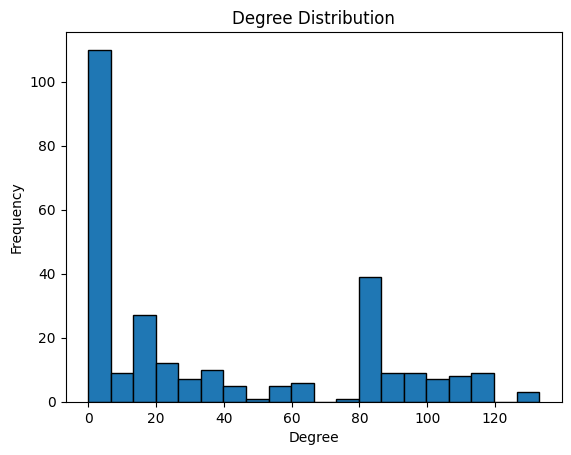

Number of connected components: 75
Size of largest connected component: 197
Average clustering coefficient: 0.5957


In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Assuming the graph G is already constructed
# Analyze the graph structure
print("=== Graph Analysis ===")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# Degree distribution
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=20, edgecolor='black')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# Connected components
connected_components = list(nx.connected_components(G))
print(f"Number of connected components: {len(connected_components)}")

# Largest connected component
largest_cc = max(connected_components, key=len)
print(f"Size of largest connected component: {len(largest_cc)}")

# Clustering coefficient
clustering_coeff = nx.average_clustering(G)
print(f"Average clustering coefficient: {clustering_coeff:.4f}")


### **Graph n Dataset Draft**

In [28]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import pandas as pd
import numpy as np
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from torch.utils.data import Dataset, DataLoader

In [30]:
import pandas as pd
import torch

# Load the full stock data
full_stock_data = pd.read_csv('full_stock_data.csv')

# Create case-insensitive mappings
company_to_ticker = {name.lower(): ticker.upper() for name, ticker in zip(full_stock_data['name'], full_stock_data['ticker'])}
text_file_to_ticker = {row['text_file_name'].lower(): row['ticker'].upper() for _, row in full_stock_data.iterrows()}

def get_ticker_embedding(ticker, fused_embeddings_dict, text_file_to_ticker):
    ticker = ticker.upper()
    for text_file, embedding in fused_embeddings_dict.items():
        if text_file_to_ticker.get(text_file.lower(), '') == ticker:
            return embedding
    return None

# Create node features (fused embeddings)
node_features = []
missing_tickers = []
for ticker in G.nodes():
    embedding = get_ticker_embedding(ticker, fused_embeddings_dict, text_file_to_ticker)
    if embedding is not None:
        node_features.append(embedding)
    else:
        missing_tickers.append(ticker)

# Convert node_features to a tensor
node_features = torch.stack([torch.tensor(emb) for emb in node_features])

print(f"Total nodes in graph: {len(G.nodes())}")
print(f"Nodes with embeddings: {len(node_features)}")
print(f"Missing embeddings: {len(missing_tickers)}")
print("Missing tickers:", missing_tickers)


Total nodes in graph: 277
Nodes with embeddings: 271
Missing embeddings: 6
Missing tickers: ['AT', 'IR', 'KORS', 'LOW', 'PG', 'SYMC.VI']


In [31]:
node_list = list(G.nodes())
edge_index = torch.tensor([[node_list.index(u), node_list.index(v)] for u, v in G.edges()]).t().contiguous()
edge_attr = torch.tensor([G[u][v]['weight'] for u, v in G.edges()])


In [32]:
# Create PyTorch Geometric Data object
data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

In [33]:
# Combine train, test, and val DataFrames
all_data = pd.concat([traindf, testdf, valdf])

# Create a dictionary mapping text_file_name to volatility data
volatility_dict = {}
for _, row in all_data.iterrows():
    future_vol = row[['future_' + str(i) for i in range(2, 31)]].values
    past_vol = row[['past_' + str(i) for i in range(2, 31)]].values
    volatility_dict[row['text_file_name']] = np.concatenate([past_vol, future_vol]).astype(np.float32)

# Create volatility_data tensor
volatility_data = torch.tensor([volatility_dict[text_file] for text_file in fused_embeddings_dict.keys() if text_file in volatility_dict])

<ipython-input-33-a468884843fe>:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  volatility_data = torch.tensor([volatility_dict[text_file] for text_file in fused_embeddings_dict.keys() if text_file in volatility_dict])


In [34]:
print(volatility_dict.popitem())

('AT&T Inc._20171024', array([-6.2252746, -5.775205 , -5.275944 , -5.1684403, -4.7593355,
       -4.8309035, -3.8744357, -3.93296  , -3.9579666, -4.0055823,
       -4.0479627, -4.078891 , -4.1077833, -4.109804 , -4.139826 ,
       -4.160848 , -4.1729827, -4.1963606, -4.2179623, -4.207278 ,
       -4.2127805, -4.2344003, -4.247955 , -4.215601 , -4.2257547,
       -4.2012787, -4.216826 , -4.2283587, -4.2279997, -3.7948372,
       -3.8200972, -3.9591103, -4.028242 , -4.1154065, -4.1855574,
       -4.221363 , -4.2655153, -4.2780967, -4.2662787, -4.228541 ,
       -4.2558193, -4.2928696, -4.3029623, -4.331328 , -4.280083 ,
       -4.308657 , -4.333088 , -4.347865 , -4.33533  , -4.358151 ,
       -4.3785133, -4.34214  , -4.270881 , -4.288358 , -4.3069887,
       -4.289813 , -4.2655373, -4.266715 ], dtype=float32))


In [35]:
full_stock_data = all_data
# Split FIRST before processing
train_cutoff = int(0.6 * len(full_stock_data))
val_cutoff = int(0.8 * len(full_stock_data))

train_df = full_stock_data[:train_cutoff]
val_df = full_stock_data[train_cutoff:val_cutoff]
test_df = full_stock_data[val_cutoff:]


def create_volatility_dict(df):
    return {
        row['text_file_name']: {
            # Match exact column names from your data
            'past': row[[f'past_{i}' for i in range(2, 30)]].values,  # past_1 to past_29
            'future': row[[f'future_{i}' for i in range(2, 30)]].values  # future_1 to future_29
        } for _, row in df.iterrows()
    }


train_vol = create_volatility_dict(train_df)
val_vol = create_volatility_dict(val_df)
test_vol = create_volatility_dict(test_df)


In [36]:
print("Node Features Shape:", node_features.shape)
print("Edge Index Shape:", edge_index.shape)
print("Edge Attributes Shape:", edge_attr.shape)
print("Volatility Data Shape:", volatility_data.shape)
print("Target Shape:", volatility_data[:, 29:].shape)

Node Features Shape: torch.Size([271, 256])
Edge Index Shape: torch.Size([2, 5199])
Edge Attributes Shape: torch.Size([5199])
Volatility Data Shape: torch.Size([558, 58])
Target Shape: torch.Size([558, 29])


### **Final Draft**

In [37]:
from torch.utils.data import Dataset, DataLoader

In [56]:
def create_volatility_dict(df):
    """Create volatility dict with 58 time steps (29 past + 29 future)"""
    return {
        row['text_file_name']: {
            'past': np.array([row[f'past_{i}'] for i in range(2,31)], dtype=np.float32),
            'future': np.array([row[f'future_{i}'] for i in range(2,31)], dtype=np.float32)
        } for _, row in df.iterrows()
    }

# def collate_fn(batch):
#     batch_size = len(batch)
#     return {
#         'node_features': batch[0]['node_features'].unsqueeze(0).expand(len(batch), -1, -1),  # [B, 309, 256]
#         'edge_index': batch[0]['edge_index'],
#         'edge_attr': batch[0]['edge_attr'],
#         'volatility_data': torch.stack([item['volatility_data'] for item in batch]),  # [B, 1, 29]
#         'target': torch.stack([item['target'] for item in batch])  # [B, 1, 29]
#     }
def collate_fn(batch):
    # Batch node features
    node_features = torch.stack([item['node_features'] for item in batch])

    # Create batched edge indices with offsets
    edge_indices = []
    num_nodes = batch[0]['node_features'].shape[0]
    for i, item in enumerate(batch):
        offset = i * num_nodes
        edge_indices.append(item['edge_index'] + offset)

    edge_index = torch.cat(edge_indices, dim=1)
    edge_attr = torch.cat([item['edge_attr'] for item in batch])

    return {
        'node_features': node_features,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'volatility_data': torch.stack([item['volatility_data'] for item in batch]),
        'target': torch.stack([item['target'] for item in batch])
    }


In [39]:
class TemporalVolatilityDataset(Dataset):
    def __init__(self, node_features, edge_index, edge_attr, volatility_dict):
        self.node_features = node_features
        self.edge_index = edge_index
        self.edge_attr = edge_attr
        self.samples = []

        # Convert volatility data to tensors
        for k in volatility_dict:
            past = torch.from_numpy(volatility_dict[k]['past'].astype(np.float32))
            future = torch.from_numpy(volatility_dict[k]['future'].astype(np.float32))
            self.samples.append((past, future))

    # ADD THIS METHOD
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        past, future = self.samples[idx]
        return {
            'node_features': self.node_features,
            'edge_index': self.edge_index,
            'edge_attr': self.edge_attr,
            'volatility_data': past.unsqueeze(0),  # [1, 29]
            'target': future.unsqueeze(0)          # [1, 29]
        }


In [40]:
# Create properly typed volatility dicts
train_vol = create_volatility_dict(train_df)
val_vol = create_volatility_dict(val_df)
test_vol = create_volatility_dict(test_df)

# Create datasets with clean data
train_dataset = TemporalVolatilityDataset(node_features, edge_index, edge_attr, train_vol)
val_dataset = TemporalVolatilityDataset(node_features, edge_index, edge_attr, val_vol)
test_dataset = TemporalVolatilityDataset(node_features, edge_index, edge_attr, test_vol)


In [41]:
print(train_dataset[0])

{'node_features': tensor([[ 13.7427,   7.9361, -43.0885,  ...,  21.5157,  -8.7248,  -3.4403],
        [ 14.4755,   7.8255, -46.6121,  ...,  19.8695,  -9.0333,  -5.9079],
        [ 15.3279,   9.6020, -48.8888,  ...,  22.8705,  -9.5535,  -6.0555],
        ...,
        [ 16.7704,   9.7647, -50.2474,  ...,  23.8632,  -9.2935,  -6.7384],
        [ 18.6303,  11.5070, -57.4569,  ...,  25.4295, -10.2539,  -8.7939],
        [ 13.0913,   7.2043, -42.6010,  ...,  18.3052,  -8.7078,  -5.5514]]), 'edge_index': tensor([[  0,   0,   0,  ..., 271, 273, 273],
        [  6,  10,  67,  ..., 274, 275, 276]]), 'edge_attr': tensor([1., 1., 1.,  ..., 1., 1., 1.]), 'volatility_data': tensor([[-4.6797, -4.8744, -5.0177, -4.8842, -4.8132, -4.8894, -4.8961, -4.8521,
         -4.9047, -4.8243, -4.7324, -4.7625, -4.7964, -4.8270, -4.8448, -4.8197,
         -4.8473, -4.7805, -4.7324, -4.7310, -4.7270, -4.6688, -4.6822, -4.6306,
         -4.6353, -4.5578, -4.5645, -4.5820, -4.5435]]), 'target': tensor([[-3.9890, -4.

In [42]:
# 2. Create Data Loaders with Correct Datasets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

In [57]:
# class GraphTemporalTransformer(nn.Module):
#     def __init__(self, input_dim, hidden_dim, output_dim=29, num_layers=3, heads=2):
#         super().__init__()
#         self.heads = heads

#         # GAT layers with proper head handling
#         self.graph_layers = nn.ModuleList([
#             GATConv(input_dim, hidden_dim//heads, heads=heads, edge_dim=1, add_self_loops=False),
#             *[GATConv(hidden_dim, hidden_dim//heads, heads=heads, edge_dim=1, add_self_loops=False)
#               for _ in range(num_layers-1)]
#         ])

#         # Volatility processor
#         self.vol_encoder = nn.Sequential(
#             nn.Linear(29, 128),
#             nn.ReLU(),
#             nn.Linear(128, hidden_dim)
#         )

#         # Final predictor
#         self.output = nn.Linear(hidden_dim*2, output_dim)

#     def forward(self, node_features, edge_index, edge_attr, volatility_data):
#         B, N, D = node_features.shape

#         # Graph processing (use reshape instead of view)
#         x = node_features.reshape(-1, D)  # Changed to reshape [B*N, D]
#         edge_index = edge_index.expand(B, -1, -1).reshape(2, -1)
#         edge_attr = edge_attr.repeat(B)

#         for conv in self.graph_layers:
#             x = conv(x, edge_index, edge_attr).relu()

#         x = x.reshape(B, N, -1).mean(dim=1)  # Changed to reshape [B, H]

#         # Volatility processing
#         vol_features = self.vol_encoder(volatility_data.squeeze(1))

#         # Combine and predict
#         combined = torch.cat([x, vol_features], dim=-1)
#         return self.output(combined)

class GraphTemporalTransformer(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, num_heads=4):
        super().__init__()
        self.graph_layers = nn.ModuleList([
            GATConv(input_dim, hidden_dim//num_heads, heads=num_heads,
                    edge_dim=1, add_self_loops=False),
            GATConv(hidden_dim, hidden_dim//num_heads, heads=num_heads,
                    edge_dim=1, add_self_loops=False)
        ])

        self.temporal_encoder = nn.Sequential(
            nn.Linear(29, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )

        self.fusion = nn.Linear(hidden_dim*2, hidden_dim)
        self.output = nn.Linear(hidden_dim, 29)

    def forward(self, node_features, edge_index, edge_attr, volatility_data):
        B, N, D = node_features.shape

        # Graph processing with proper batch handling
        x = node_features.view(B*N, D)
        edge_attr = edge_attr.repeat_interleave(B)  # Correct attribute alignment

        for conv in self.graph_layers:
            x = conv(x, edge_index, edge_attr).relu()

        graph_feat = x.view(B, N, -1).mean(dim=1)

        # Temporal processing
        temporal_feat = self.temporal_encoder(volatility_data.squeeze(1))

        # Fusion
        combined = torch.cat([graph_feat, temporal_feat], dim=-1)
        return self.output(combined)


In [44]:
# 2. Verify data dimensions
print("Volatility data shape:", train_dataset[0]['volatility_data'].shape)  # Should be [1, 29]
print("Target shape:", train_dataset[0]['target'].shape)                    # Should be [1, 29]

Volatility data shape: torch.Size([1, 29])
Target shape: torch.Size([1, 29])


In [45]:
# Initialize model with correct dimensions
model = GraphTemporalTransformer(input_dim=256, hidden_dim=128)

# Enhanced optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=2)
num_epochs = 10

In [58]:
def train_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Compute target statistics
    train_future_vols = np.concatenate([v['future'] for v in train_vol.values()])
    target_mean = np.mean(train_future_vols)
    target_std = np.std(train_future_vols)

    model = GraphTemporalTransformer(hidden_dim=256).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)

    best_val = float('inf')
    for epoch in range(100):
        model.train()
        total_loss = 0

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()
            preds = model(
                batch['node_features'],
                batch['edge_index'],
                batch['edge_attr'],
                batch['volatility_data']
            )

            loss = F.mse_loss(preds, batch['target'].squeeze(1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            total_loss += loss.item()

        # Validation
        val_metrics = evaluate_horizons(model, val_loader, target_mean, target_std)
        val_score = sum(val_metrics[h]['mse'] for h in [3,7,15,30])

        print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f}")
        print(f"Val MSE: {val_score:.4f}")

        if val_score < best_val:
            best_val = val_score
            torch.save(model.state_dict(), "best_model.pth")

    return model


In [46]:
from sklearn.metrics import mean_absolute_error, r2_score

def full_evaluate(model, loader):
    model.eval()
    total_mse = 0
    total_mae = 0
    total_r2 = 0

    with torch.no_grad():
        for batch in loader:
            pred = model(batch['node_features'], batch['edge_index'],
                        batch['edge_attr'], batch['volatility_data'])
            true = batch['target'].squeeze(1)

            # Flatten for regression metrics
            true_flat = true.cpu().numpy().reshape(-1)
            pred_flat = pred.cpu().numpy().reshape(-1)

            total_mse += F.mse_loss(pred, true).item()
            total_mae += mean_absolute_error(true_flat, pred_flat)
            total_r2 += r2_score(true_flat, pred_flat)

    return {
        'mse': total_mse / len(loader),
        'mae': total_mae / len(loader),
        'r2': total_r2 / len(loader)
    }


In [47]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        pred = model(
            batch['node_features'],
            batch['edge_index'],
            batch['edge_attr'],
            batch['volatility_data']
        )

        loss = F.mse_loss(pred, batch['target'].squeeze(1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        total_loss += loss.item()

    # Validation
    val_metrics = full_evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val MSE: {val_metrics['mse']:.4f} | Val R²: {val_metrics['r2']:.2f}")
    scheduler.step(val_metrics['mse'])


Epoch 1 | Train Loss: 20.1922 | Val MSE: 18.0339 | Val R²: -61.54
Epoch 2 | Train Loss: 17.7163 | Val MSE: 15.5453 | Val R²: -52.88
Epoch 3 | Train Loss: 15.1914 | Val MSE: 13.0270 | Val R²: -44.14
Epoch 4 | Train Loss: 12.6008 | Val MSE: 10.3674 | Val R²: -34.93
Epoch 5 | Train Loss: 9.8452 | Val MSE: 7.6058 | Val R²: -25.38
Epoch 6 | Train Loss: 6.9176 | Val MSE: 4.9257 | Val R²: -16.11
Epoch 7 | Train Loss: 4.2926 | Val MSE: 2.6492 | Val R²: -8.22
Epoch 8 | Train Loss: 2.1389 | Val MSE: 1.1809 | Val R²: -3.09
Epoch 9 | Train Loss: 0.9095 | Val MSE: 0.5905 | Val R²: -0.99
Epoch 10 | Train Loss: 0.4025 | Val MSE: 0.3410 | Val R²: -0.13


In [48]:

# Test evaluation
test_metrics = full_evaluate(model, test_loader)
print(f"Test MSE: {test_metrics['mse']:.4f}")
print(f"Test MAE: {test_metrics['mae']:.4f}")
print(f"Test R²: {test_metrics['r2']:.2f}")



Test MSE: 0.2924
Test MAE: 0.4096
Test R²: -0.05


In [49]:
print(model)

GraphTemporalTransformer(
  (graph_layers): ModuleList(
    (0): GATConv(256, 64, heads=2)
    (1-2): 2 x GATConv(128, 64, heads=2)
  )
  (vol_encoder): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (output): Linear(in_features=256, out_features=29, bias=True)
)


In [50]:
def evaluate_horizons(model, loader, target_mean, target_std, horizons=[3,7,15,30]):
    model.eval()
    results = {h: {'mse': 0.0, 'mae': 0.0, 'r2': 0.0} for h in horizons}
    counts = {h: 0 for h in horizons}

    # Map horizon days to indices (future starts at day 2)
    horizon_indices = {h: h-2 for h in horizons}  # day 3 -> index 1, day 7->5, etc.

    with torch.no_grad():
        for batch in loader:
            pred = model(
                batch['node_features'],
                batch['edge_index'],
                batch['edge_attr'],
                batch['volatility_data']
            )
            true = batch['target'].squeeze(1)

            # Denormalize predictions and targets
            pred_denorm = pred * target_std + target_mean
            true_denorm = true * target_std + target_mean

            for h in horizons:
                idx = horizon_indices[h]
                if idx >= pred_denorm.shape[1]:
                    continue  # Skip if horizon exceeds prediction length

                pred_h = pred_denorm[:, idx]
                true_h = true_denorm[:, idx]

                results[h]['mse'] += F.mse_loss(pred_h, true_h).item()
                results[h]['mae'] += F.l1_loss(pred_h, true_h).item()
                results[h]['r2'] += r2_score(true_h.cpu().numpy(),
                                           pred_h.cpu().numpy())
                counts[h] += 1

    # Average metrics
    for h in horizons:
        if counts[h] > 0:
            results[h]['mse'] /= counts[h]
            results[h]['mae'] /= counts[h]
            results[h]['r2'] /= counts[h]

    return results

# Compute target stats from training data
train_future_vols = np.concatenate([v['future'] for v in train_vol.values()])
target_mean = np.mean(train_future_vols)
target_std = np.std(train_future_vols)

# Get metrics
horizon_metrics = evaluate_horizons(model, test_loader, target_mean, target_std)

# Print formatted results
print(f"{'Model':<15} {'MSE3':<8} {'MSE7':<8} {'MSE15':<8} {'MSE30':<8} {'R2_3':<8} {'R2_7':<8} {'R2_15':<8} {'R2_30':<8}")
print(f"{'CallGAP':<15}", end='')
for h in [3,7,15,30]:
    print(f"{horizon_metrics[h]['mse']:.2f}  ", end='')
for h in [3,7,15,30]:
    print(f"{horizon_metrics[h]['r2']:.2f}  ", end='')


Model           MSE3     MSE7     MSE15    MSE30    R2_3     R2_7     R2_15    R2_30   
CallGAP        0.22  0.10  0.07  0.06  -0.04  0.02  0.04  -0.31  